In [2]:
import numpy as np
import scanpy as sc
import scvelo as scv
import anndata as ad
import pandas as pd
import scipy
import os
import torch
from matplotlib import pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from umap import UMAP
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import sys; sys.path += ['./../../']
from CardamomOT import NetworkModel as CardamomNetworkModel
from CardamomOT.inference.simulations import kon_ref, simulate_next_prot_ode
from harissa import NetworkModel as HarissaNetworkModel
sys.path.append("./_scripts/") 
import rf

In [2]:
cmap = plt.get_cmap('tab20')
colors_methods = {'CardamomOT': (cmap(6), cmap(7)), 'CARDAMOM1': (cmap(8), cmap(9)),'REFERENCE_FITTING': (cmap(18), cmap(19)),
    'GENIE3': (cmap(0), cmap(1)), 'SINCERITIES': (cmap(2), cmap(3)),
    'PIDC': (cmap(4), cmap(5)), 'PEARSON': (cmap(14), cmap(15)),
    'SCRIBE_timed': (cmap(10), cmap(11)), 'SCRIBE_wadd': (cmap(12), cmap(13)),
    'SCRIBE_pseudotimed': (cmap(16), cmap(17)), 'Random': 2*('lightgray',)}

In [ ]:
def step_ode_modif(d1, ks, inter, basal, scale, P):
    """Euler step for the deterministic limit model."""
    a = kon_ref(P, ks, inter, basal)
    delta_P = d1 * (scale * a - P)
    return P + delta_P, delta_P

def kon_harissa(basal, inter, k0, k1, P):
    """Compute the kon rates according to the Harissa model."""
    phi = 1 / (1 + np.exp(-(basal + P @ inter)))
    kon = k0 + (k1 - k0) * phi
    kon[0] = 0
    return kon

def compute_similarity_matrix(deltas):
    """Weighted cosine similarity matrix for a list of delta arrays."""
    n = len(deltas)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            norms = np.linalg.norm(deltas[i], axis=1) * np.linalg.norm(deltas[j], axis=1)
            weights = norms / norms.sum()
            matrix[i, j] = np.sum(cosine_similarity(deltas[i], deltas[j]).diagonal() * weights)
    return matrix

def fit_transform_umap(base, *endpoints, **umap_kwargs):
    """Fit a UMAP on the union of base + endpoints, return (base_2d, [delta_2d, ...])."""
    umap = UMAP(**umap_kwargs)
    umap.fit(np.vstack([base, *endpoints]))
    base_2d = umap.transform(base)
    deltas_2d = [umap.transform(ep) - base_2d for ep in endpoints]
    return base_2d, deltas_2d

def run_fig_5(run_name):
    # ---- Harissa deltas ----
    k0_h = model_harissa.a[0] * model_harissa.d[0]
    k1_h = model_harissa.a[1] * model_harissa.d[0]
    delta_rna_harissa  = np.zeros_like(rna_traj, dtype=float)
    delta_prot_harissa = np.zeros_like(prot_traj_scaled, dtype=float)
    for n, cell in enumerate(prot_traj_scaled):
        kon = kon_harissa(model_harissa.basal, model_harissa.inter, k0_h, k1_h, cell)
        delta_rna_harissa[n]  = kon / model_harissa.a[-1] - model_harissa.d[0] * rna_traj[n]
        delta_prot_harissa[n] = model_harissa.d[1] * (kon / k1_h - cell)

    # ---- CardamomOT fit ----
    time = data[1:, 0]
    x = data[1:, 1:].copy()
    x[:, 0] = time
    G = x.shape[1]
    model = CardamomNetworkModel(G - 1)
    model.d = np.loadtxt('BN8/Data/Rates/degradation_rates.txt', dtype=float, delimiter='\t').T[:, :rna_traj.shape[1]]
    print(x.shape)
    model.fit_mixture(x, min_components=2, max_components=2, max_iter_kinetics=0)
    model.fit_network(x, intensity_prior=100)
    model.adapt_to_unitary()

    # ---- Carda deltas ----
    c       = model.a[-1]
    ks_cells = np.max(model.a[:-1], axis=0)
    ks      = (model.a[:-1] / ks_cells).T
    delta_rna_carda  = model.d[0] * (model.kon_theta * ks_cells / c - rna_traj)
    delta_prot_carda = np.zeros_like(prot_traj_scaled, dtype=float)
    for cell in range(prot_traj_scaled.shape[0]):
        _, delta_P = step_ode_modif(model.d[1], ks, model.inter, model.basal, 1,
                                    prot_traj_scaled[cell].reshape(1, -1))
        delta_prot_carda[cell] = delta_P[0]

    # ---- Reference Fitting ----
    adata_rf = ad.AnnData(X=rna_traj, obs={'time': time})
    options = dict(lr=0.05, reg_sinkhorn=0.1, reg_A=1, reg_A_elastic=0.5, iter=1000,
                   ot_coupling=True, optimizer=torch.optim.Adam, n_pca_components=-1)
    estim = rf.Estimator([adata_rf], kos=[None], lr=options['lr'],
                         reg_sinkhorn=options['reg_sinkhorn'], reg_A=options['reg_A'],
                         reg_A_elastic=options['reg_A_elastic'], iter=options['iter'],
                         ot_coupling=options['ot_coupling'], optimizer=options['optimizer'],
                         norm=False, t_key='time')
    estim.fit(print_iter=10, alg='alternating', update_couplings_iter=250)

    P_rf   = np.array(torch.linalg.matrix_exp(1 / estim.T * estim.A.cpu()))
    b_rf   = estim.b.cpu().numpy()
    scaler = [1, 1]

    # Strip stimulus column
    delta_rna_rf    = (rna_traj    @ P_rf + b_rf - rna_traj)[:, 1:]    * scaler[0]
    delta_prot_rf   = (prot_traj_scaled @ P_rf + b_rf - prot_traj_scaled)[:, 1:] * scaler[1]
    delta_rna_carda_s  = delta_rna_carda[:, 1:]
    delta_prot_carda_s = delta_prot_carda[:, 1:]
    delta_rna_h_s   = delta_rna_harissa[:, 1:]
    delta_prot_h_s  = delta_prot_harissa[:, 1:]

    # Reffit per-cell OT coupling correction
    unique_times = np.unique(time)
    for number, cell in enumerate(prot_traj_scaled):
        if number // 100 < len(unique_times) - 1:
            P2 = (np.dot(estim.Ts[0][number // 100][number % 100].cpu().numpy(),
                         prot_traj_scaled[100 * (number // 100):100 * (number // 100 + 1)]) * 100)[1:]
            delta_prot_rf[number] = (P2 - cell[1:]) * scaler[1]

    rna_s  = rna_traj[:, 1:]
    prot_s = prot_traj_scaled[:, 1:]

    # ---- Subsample ----
    n_sub = 100
    np.random.seed(42)
    sub_idx = np.concatenate([
        np.random.choice(np.where(time == t)[0], size=min(n_sub, (time == t).sum()), replace=False)
        for t in unique_times[1:]
    ])
    time_sub         = time[sub_idx]
    rna_sub          = rna_s[sub_idx]
    prot_sub         = prot_s[sub_idx]
    d_rna_carda_sub  = delta_rna_carda_s[sub_idx]
    d_prot_carda_sub = delta_prot_carda_s[sub_idx]
    d_rna_h_sub      = delta_rna_h_s[sub_idx]
    d_prot_h_sub     = delta_prot_h_s[sub_idx]
    d_rna_rf_sub     = delta_rna_rf[sub_idx]
    d_prot_rf_sub    = delta_prot_rf[sub_idx]

    # ---- UMAP embeddings ----
    umap_kw = dict(n_components=2, random_state=42, min_dist=0.7)
    rna_2d, (d_rna_rf_2d, d_rna_carda_2d, d_rna_h_2d) = fit_transform_umap(
        rna_sub,
        rna_sub + d_rna_rf_sub * 0.5,
        rna_sub + d_rna_carda_sub,
        rna_sub + d_rna_h_sub,
        **umap_kw)
    prot_2d, (d_prot_rf_2d, d_prot_carda_2d, d_prot_h_2d) = fit_transform_umap(
        prot_sub,
        prot_sub + d_prot_rf_sub * 0.2,
        prot_sub + d_prot_carda_sub,
        prot_sub + d_prot_h_sub,
        **umap_kw)

    # ---- Figure 1: velocity quiver plots ----
    fig, axes = plt.subplots(3, 2, figsize=(14, 13))
    plot_cfg = [
        (axes[0, 0], rna_2d,  d_rna_h_2d,      'UMAP of RNA trajectories - Harissa'),
        (axes[0, 1], prot_2d, d_prot_h_2d,      'UMAP of Protein trajectories - Harissa'),
        (axes[1, 0], rna_2d,  d_rna_carda_2d,   'UMAP of RNA trajectories - CARDA'),
        (axes[1, 1], prot_2d, d_prot_carda_2d,  'UMAP of Protein trajectories - CARDA'),
        (axes[2, 0], rna_2d,  d_rna_rf_2d,      'UMAP of RNA trajectories - ReferenceFitting'),
        (axes[2, 1], prot_2d, d_prot_rf_2d,     'UMAP of Protein trajectories - ReferenceFitting'),
    ]
    for ax, emb, vel, title in plot_cfg:
        sc = ax.scatter(emb[:, 0], emb[:, 1], c=time_sub, cmap='viridis', alpha=0.6, s=15)
        ax.quiver(emb[:, 0], emb[:, 1], vel[:, 0], vel[:, 1],
                  angles='xy', scale_units='xy', scale=1, width=0.002, color='tab:red', alpha=0.6)
        ax.set(xlabel='UMAP 1', ylabel='UMAP 2', title=title)
        plt.colorbar(sc, ax=ax, label='Time')
    plt.tight_layout()
    plt.savefig(f'figure_5_1_{run_name}.pdf', dpi=300)
    plt.show()

    # ---- Figure 2: cosine similarity heatmaps ----
    not_last = time != unique_times[-1]
    methods = ['RefFit', 'CARDA', 'Harissa']
    sim_rna  = compute_similarity_matrix([delta_rna_rf[not_last],    delta_rna_carda_s[not_last],  delta_rna_h_s[not_last]])
    sim_prot = compute_similarity_matrix([delta_prot_rf[not_last],   delta_prot_carda_s[not_last], delta_prot_h_s[not_last]])

    fig, axes_hm = plt.subplots(1, 2, figsize=(14, 5))
    for ax, matrix, title in [
        (axes_hm[0], sim_rna,  'Cosine Similarity of RNA Deltas'),
        (axes_hm[1], sim_prot, 'Cosine Similarity of Protein Deltas'),
    ]:
        sns.heatmap(matrix, annot=True, fmt='.4f', cmap='gray', vmin=0, vmax=1,
                    xticklabels=methods, yticklabels=methods,
                    cbar_kws={'label': 'Cosine Similarity'}, ax=ax)
        ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'figure_5_2_{run_name}.pdf', dpi=300)
    plt.show()

    UMAPs = {'rna': rna_2d,   'prot': prot_2d,
             'rna_reffit': d_rna_rf_2d,   'prot_reffit': d_prot_rf_2d,
             'rna_carda':  d_rna_carda_2d, 'prot_carda':  d_prot_carda_2d,
             'rna_harissa': d_rna_h_2d,   'prot_harissa': d_prot_h_2d}
    cells = {'rna': rna_sub,  'prot': prot_sub,
             'rna_reffit': d_rna_rf_sub,   'prot_reffit': d_prot_rf_sub,
             'rna_carda':  d_rna_carda_sub, 'prot_carda':  d_prot_carda_sub,
             'rna_harissa': d_rna_h_sub,   'prot_harissa': d_prot_h_sub}

    return sim_rna, sim_prot, UMAPs, cells

# BN8

In [4]:
np.random.seed(0)

# Number of cells
C = 1000

# Time points
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96] 
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 8

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 0.25
model_harissa.d[1] = 0.05

model_harissa.basal[1:] = [-4, -4, -4, -4, -4, -4, -4, -4]
model_harissa.inter[0, 1] = 10
model_harissa.inter[1, 2] = 10
model_harissa.inter[1, 3] = 10
model_harissa.inter[3, 2] = -10
model_harissa.inter[2, 3] = -10
model_harissa.inter[2, 2] = 5
model_harissa.inter[3, 3] = 5
model_harissa.inter[2, 4] = 10
model_harissa.inter[3, 5] = 10
model_harissa.inter[2, 5] = -10
model_harissa.inter[3, 4] = -10
model_harissa.inter[4, 7] = -10
model_harissa.inter[5, 6] = -10
model_harissa.inter[4, 6] = 10
model_harissa.inter[5, 7] = 10
model_harissa.inter[7, 8] = 10
model_harissa.inter[6, 8] = -10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj = np.ones((C, G+1), dtype='float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj = data[1:,1:].copy()
prot_traj_scaled = prot_traj / np.max(prot_traj, axis=0)

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]


(1000, 9)


2026-03-05 15:17:06.694541: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:06.696882: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:06.750257: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:06.756163: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:06.799746: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:06.819755: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:06.858838: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:06.866920: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Calibrating gene 7
Calibrating gene 2
Calibrating gene 5
Calibrating gene 4
Calibrating gene 3
Calibrating gene 8
Calibrating gene 1
Calibrating gene 6
Gene 1-1 calibrated... [0.032 1.998] 0.018844425083683173 0.0 {0: array([0.93, 0.07]), 6: array([0.16, 0.84]), 12: array([0.028, 0.972]), 24: array([0.02, 0.98]), 36: array([0.003, 0.997]), 48: array([0.056, 0.944]), 60: array([0.06, 0.94]), 72: array([0.002, 0.998]), 84: array([0.009, 0.991]), 96: array([0.071, 0.929])}
Gene 2-2 calibrated... [0.009 1.067] 0.013063583793610997 0.0 {0: array([0.928, 0.072]), 6: array([0.91, 0.09]), 12: array([0.542, 0.458]), 24: array([0.254, 0.746]), 36: array([0.103, 0.897]), 48: array([0.214, 0.786]), 60: array([0.199, 0.801]), 72: array([0.07, 0.93]), 84: array([0.173, 0.827]), 96: array([0.203, 0.797])}
Gene 3-3 calibrated... [0.009 1.15 ] 0.01500749677432194 0.0 {0: array([0.963, 0.037]), 6: array([0.836, 0.164]), 12: array([0.572, 0.428]), 24: array([0.319, 0.681]), 36: array([0.069, 0.931]), 48:

2026-03-05 15:17:42.643021: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:42.963008: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:42.988910: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:43.009117: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:43.012108: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:43.031085: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:43.048013: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:17:43.063719: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


1 0 | Errors (before, after): 0.69347, 0.34606 | alpha mean: 0.0100
number of non reached cells 343


2026-03-05 15:18:03.097608: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:18:03.099889: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:18:03.115802: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-03-05 15:18:03.136088: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


2 0 | Errors (before, after): 0.29413, 0.27888 | alpha mean: 0.0590
number of non reached cells 321
3 0 | Errors (before, after): 0.25116, 0.24763 | alpha mean: 0.0905
number of non reached cells 336
4 0 | Errors (before, after): 0.23693, 0.22968 | alpha mean: 0.1219
number of non reached cells 339
5 0 | Errors (before, after): 0.21017, 0.20218 | alpha mean: 0.1498
number of non reached cells 338
6 0 | Errors (before, after): 0.18669, 0.18418 | alpha mean: 0.1750
number of non reached cells 323
7 0 | Errors (before, after): 0.17494, 0.17403 | alpha mean: 0.1983
number of non reached cells 329
8 0 | Errors (before, after): 0.17275, 0.17140 | alpha mean: 0.2281
number of non reached cells 328
9 0 | Errors (before, after): 0.15731, 0.15551 | alpha mean: 0.2516
number of non reached cells 321
10 0 | Errors (before, after): 0.15274, 0.15221 | alpha mean: 0.2716
number of non reached cells 330
11 0 | Errors (before, after): 0.15168, 0.14952 | alpha mean: 0.2842
number of non reached cells 30

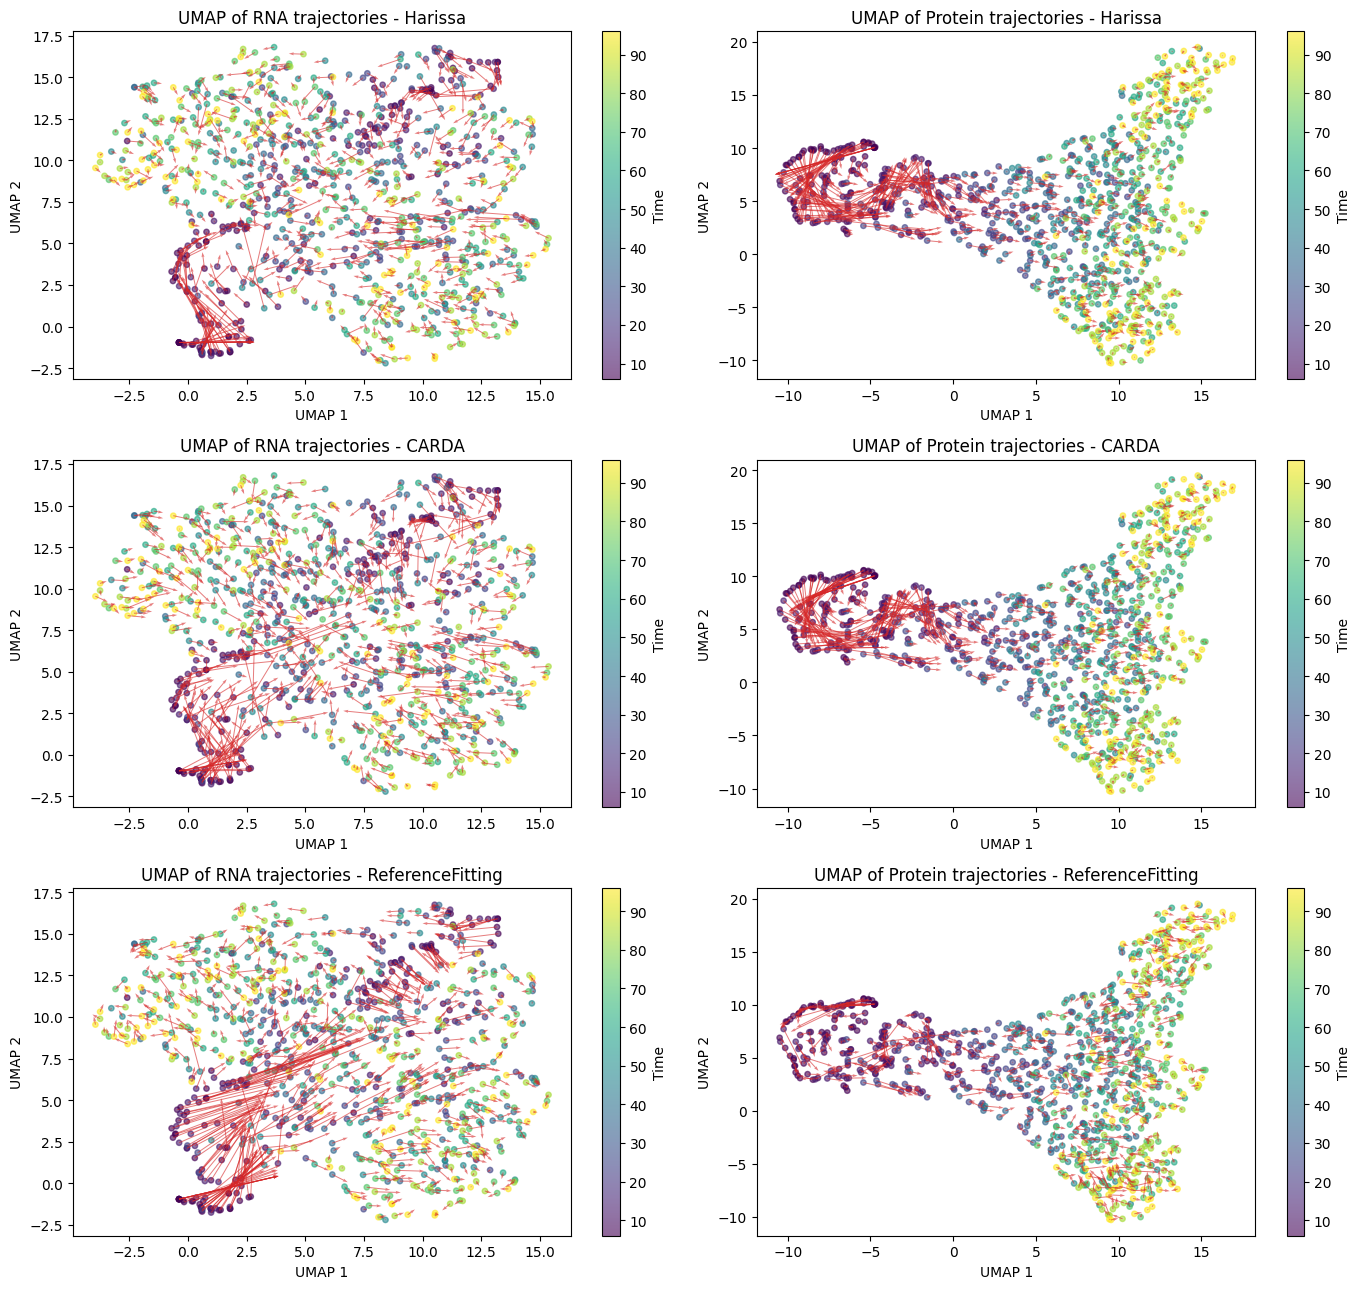

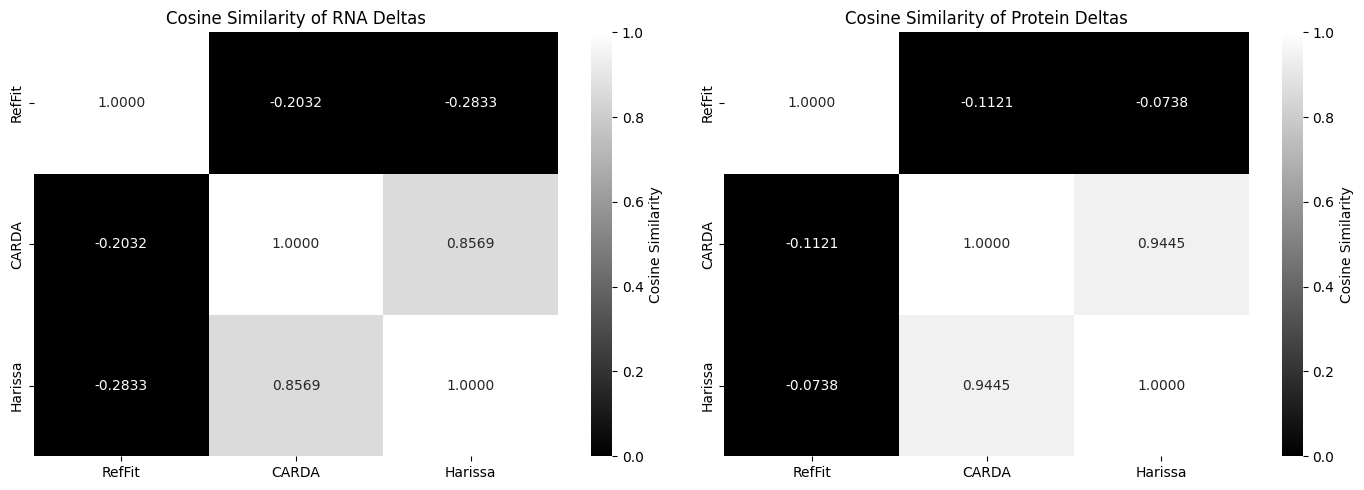

In [5]:
BN8_RNA, BN8_prot, BN8_UMAPs, BN8_cells = run_fig_5('BN8')

# FN8

In [6]:
np.random.seed(0)

# Number of cells
C = 1000
# Time points
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96] # np.linspace(0, 25, 10, dtype='int')
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 8

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 0.4
model_harissa.d[1] = 0.08

model_harissa.basal[1:] = [-5, -5, -5, -5, -5, -5, -5, -5]
model_harissa.inter[0, 1] = 10
model_harissa.inter[1, 2] = 10
model_harissa.inter[2, 3] = 10
model_harissa.inter[3, 4] = 10
model_harissa.inter[3, 5] = 10
model_harissa.inter[3, 6] = 10
model_harissa.inter[4, 1] = -10
model_harissa.inter[5, 1] = -10
model_harissa.inter[6, 1] = -10
model_harissa.inter[4, 4] = 10
model_harissa.inter[5, 5] = 10
model_harissa.inter[6, 6] = 10
model_harissa.inter[4, 8] = -10
model_harissa.inter[4, 7] = -10
model_harissa.inter[6, 7] = 10
model_harissa.inter[7, 6] = 10
model_harissa.inter[8, 8] = 10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj = np.ones((C, G+1), dtype='float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj = data[1:,1:].copy()
prot_traj_scaled = prot_traj / np.max(prot_traj, axis=0)

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]


(1000, 9)
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Calibrating gene 6
Calibrating gene 7
Calibrating gene 8
Gene 1-1 calibrated... [0.017 1.972] 0.01956758094691109 0.0 {0: array([0.974, 0.026]), 6: array([0.117, 0.883]), 12: array([0.007, 0.993]), 24: array([0.096, 0.904]), 36: array([0.207, 0.793]), 48: array([0.53, 0.47]), 60: array([0.773, 0.227]), 72: array([0.929, 0.071]), 84: array([0.959, 0.041]), 96: array([0.98, 0.02])}
Gene 2-2 calibrated... [0.009 1.63 ] 0.01886891936160474 0.0 {0: array([0.981, 0.019]), 6: array([0.828, 0.172]), 12: array([0.511, 0.489]), 24: array([0.07, 0.93]), 36: array([0.013, 0.987]), 48: array([0.122, 0.878]), 60: array([0.473, 0.527]), 72: array([0.673, 0.327]), 84: array([0.801, 0.199]), 96: array([0.897, 0.103])}
Gene 3-3 calibrated... [0.007 1.075] 0.014347874292772983 0.0 {0: array([0.974, 0.026]), 6: array([0.953, 0.047]), 12: array([0.942, 0.058]), 24: array([0.529, 0.471]), 36: array([0.15

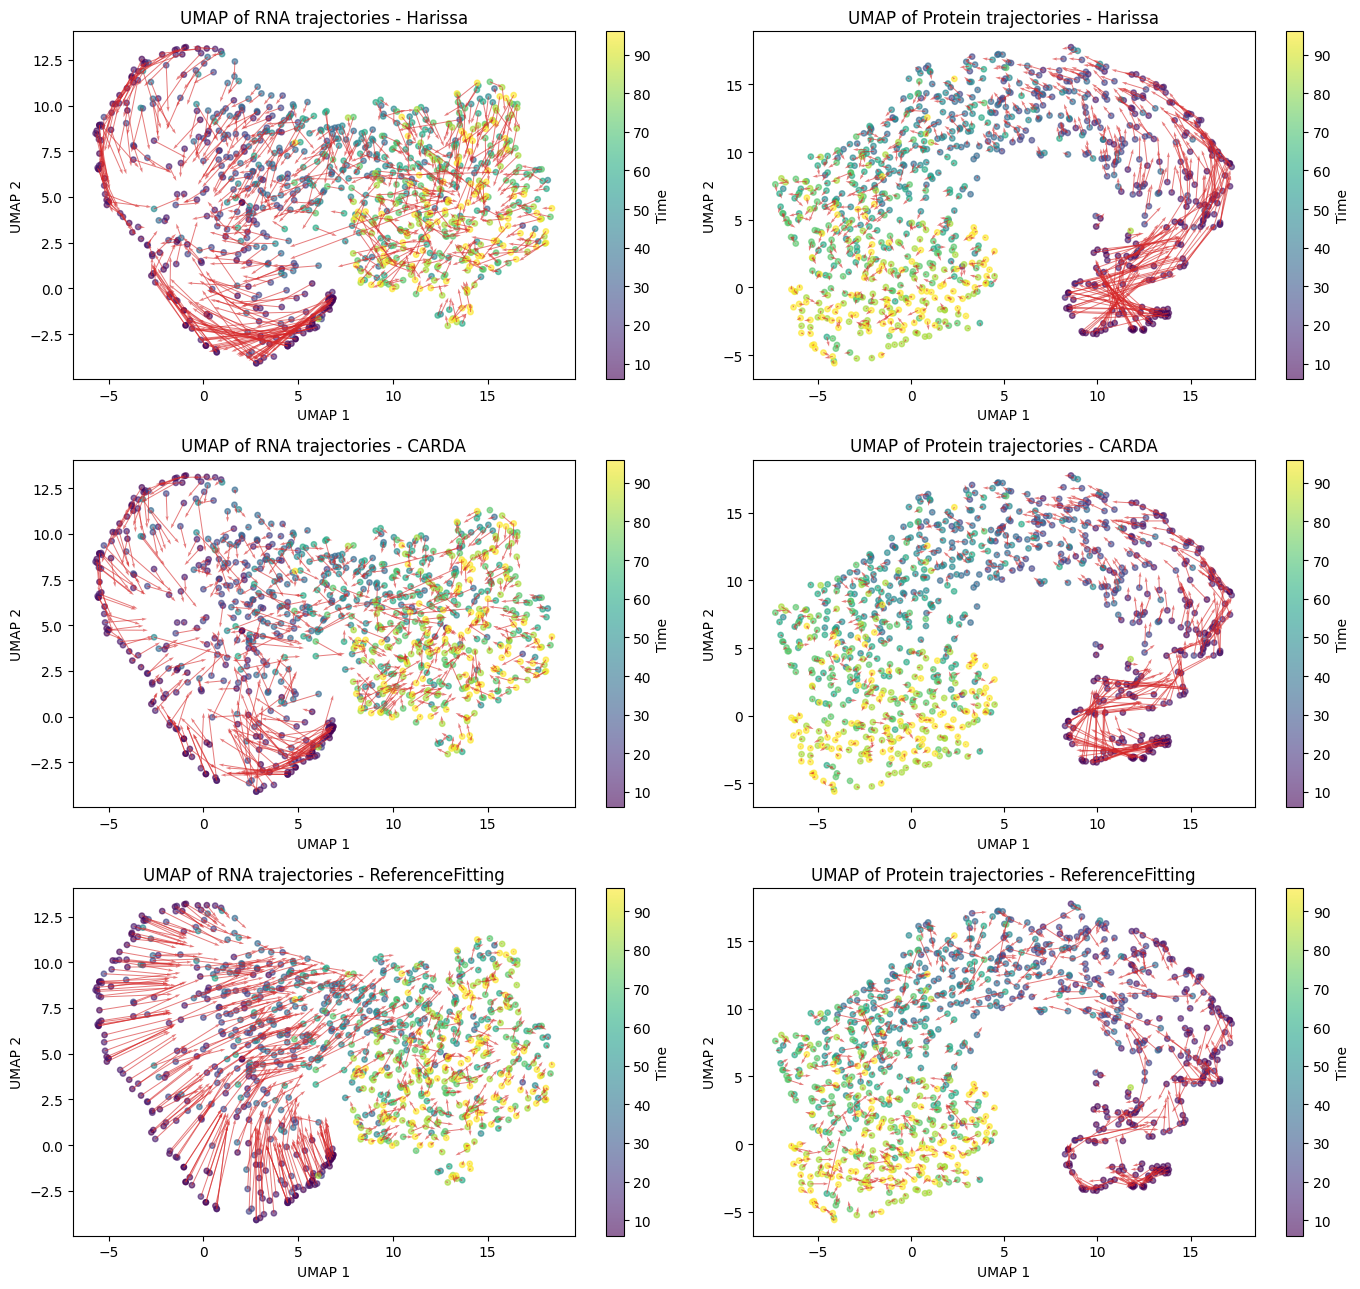

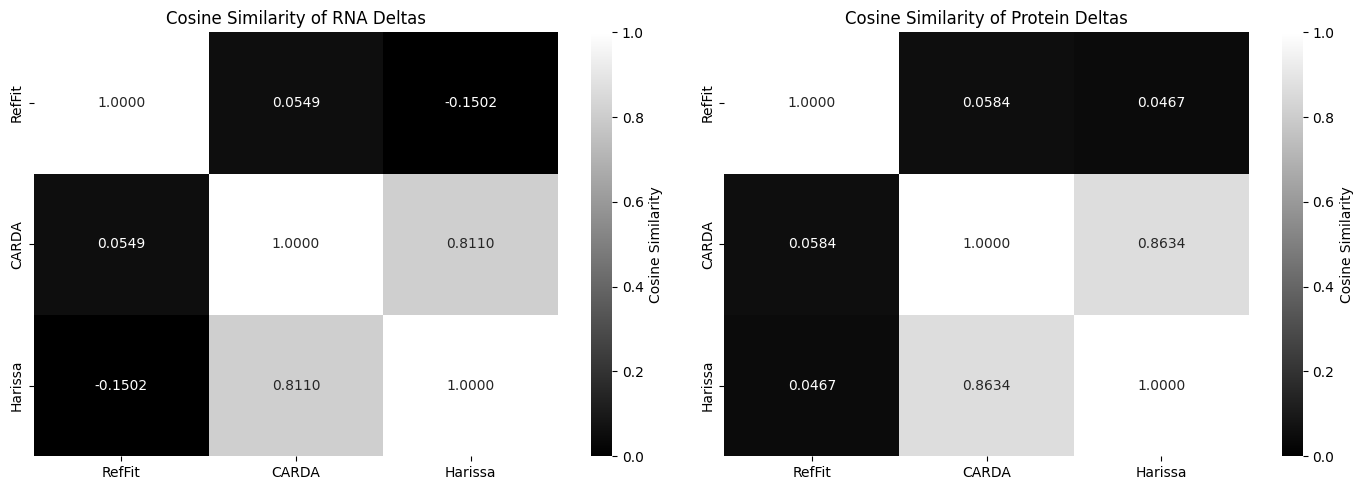

In [7]:
FN8_RNA, FN8_prot, FN8_UMAPs, FN8_cells = run_fig_5('FN8')

# CN5

In [8]:
np.random.seed(0)

# Number of cells
C = 1000
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 5

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 0.5
model_harissa.d[1] = 0.1

model_harissa.basal[1:] = [-5, 4, 4, -5, -5]
model_harissa.inter[0, 1] = 10
model_harissa.inter[1, 2] = -10
model_harissa.inter[2, 3] = -10
model_harissa.inter[3, 4] = 10
model_harissa.inter[4, 5] = 10
model_harissa.inter[5, 1] = -10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj = np.ones((C, G+1), dtype='float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj = data[1:,1:].copy()
prot_traj_scaled = prot_traj / np.max(prot_traj, axis=0)

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]


(1000, 6)
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Gene 1-1 calibrated... [0.01  1.945] 0.019497825030839896 0.0 {0: array([0.973, 0.027]), 6: array([0.015, 0.985]), 12: array([0.005, 0.995]), 24: array([0.103, 0.897]), 36: array([0.125, 0.875]), 48: array([0.416, 0.584]), 60: array([0.472, 0.528]), 72: array([0.519, 0.481]), 84: array([0.541, 0.459]), 96: array([0.53, 0.47])}
Gene 2-2 calibrated... [0.153 2.643] 0.027811985883679828 0.0 {0: array([0.058, 0.942]), 6: array([0.21, 0.79]), 12: array([0.652, 0.348]), 24: array([0.872, 0.128]), 36: array([0.843, 0.157]), 48: array([0.8, 0.2]), 60: array([0.654, 0.346]), 72: array([0.438, 0.562]), 84: array([0.339, 0.661]), 96: array([0.302, 0.698])}
Gene 3-3 calibrated... [0.318 2.965] 0.02940504077490476 0.0 {0: array([0.257, 0.743]), 6: array([0.561, 0.439]), 12: array([0.79, 0.21]), 24: array([0.361, 0.639]), 36: array([0.132, 0.868]), 48: array([0.162, 0.838]), 60: array([0.228, 0.7

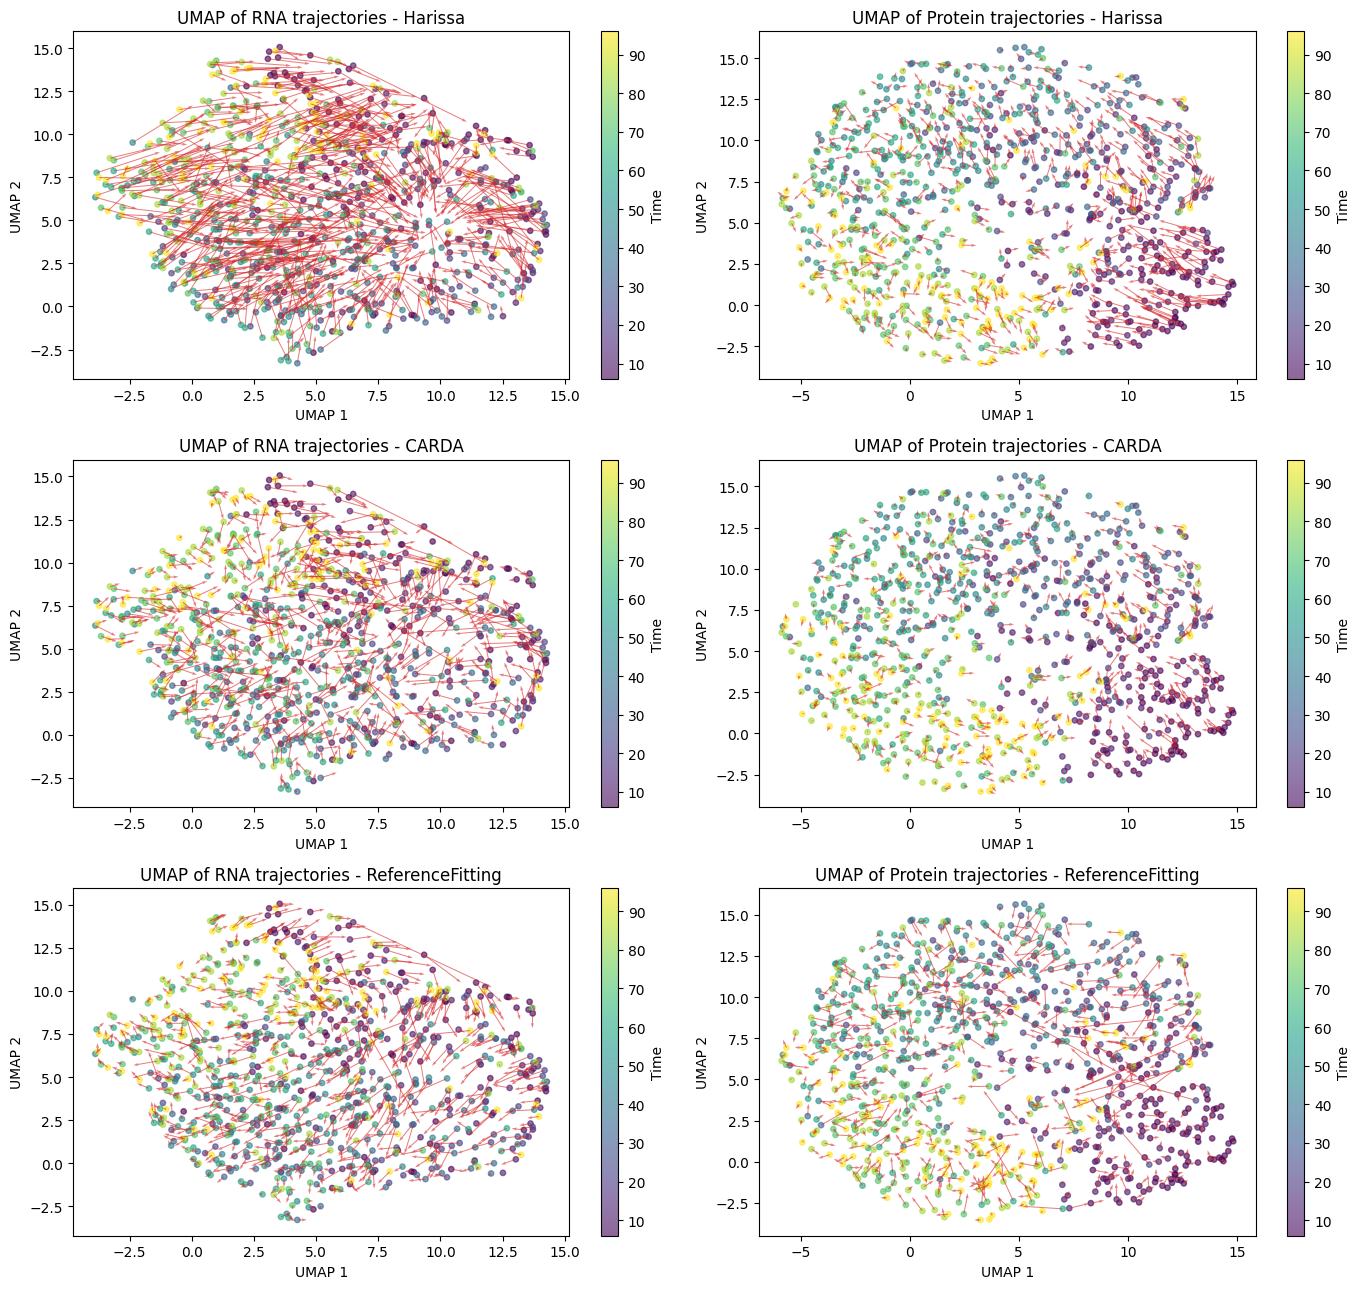

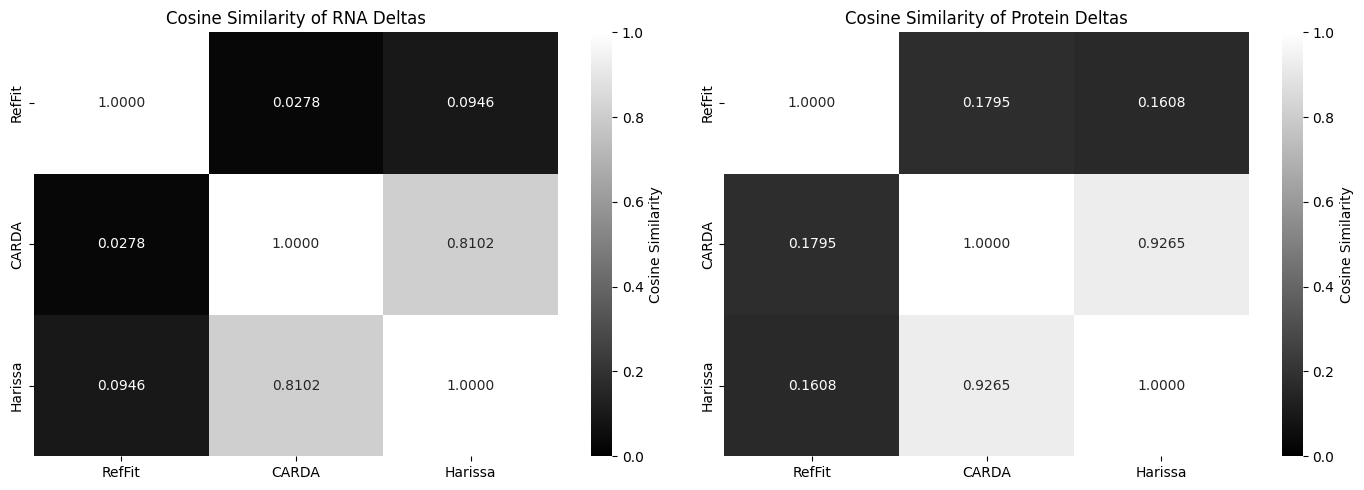

In [9]:
CN5_RNA, CN5_prot, CN5_UMAPs, CN5_cells = run_fig_5('CN5')

# FN4

In [10]:
np.random.seed(0)

# Number of cells
C = 1000
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 5

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 1
model_harissa.d[1] = 0.2
model_harissa.d /= 5

model_harissa.basal[1:] = -5
model_harissa.inter[0,1] = 10
model_harissa.inter[1,2] = 10
model_harissa.inter[1,3] = 10
model_harissa.inter[3,4] = 10
model_harissa.inter[4,1] = -10
model_harissa.inter[2,2] = 10
model_harissa.inter[3,3] = 10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj = np.ones((C, G+1), dtype='float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj = data[1:,1:].copy()
prot_traj_scaled = prot_traj / np.max(prot_traj, axis=0)

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]


(1000, 6)
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Gene 1-1 calibrated... [0.012 2.18 ] 0.023430511322963834 0.0 {0: array([0.999, 0.001]), 6: array([0.255, 0.745]), 12: array([0.006, 0.994]), 24: array([0.04, 0.96]), 36: array([0.068, 0.932]), 48: array([0.027, 0.973]), 60: array([0.04, 0.96]), 72: array([0.115, 0.885]), 84: array([0.46, 0.54]), 96: array([0.481, 0.519])}
Gene 2-2 calibrated... [0.011 2.75 ] 0.022870860589010104 0.0 {0: array([0.982, 0.018]), 6: array([0.983, 0.017]), 12: array([0.839, 0.161]), 24: array([0.522, 0.478]), 36: array([0.291, 0.709]), 48: array([0.128, 0.872]), 60: array([0.178, 0.822]), 72: array([0.174, 0.826]), 84: array([0.005, 0.995]), 96: array([0.121, 0.879])}
Gene 3-3 calibrated... [0.011 2.205] 0.02148792463911342 0.0 {0: array([0.981, 0.019]), 6: array([0.977, 0.023]), 12: array([0.803, 0.197]), 24: array([0.516, 0.484]), 36: array([0.223, 0.777]), 48: array([0.121, 0.879]), 60: array([0.095,

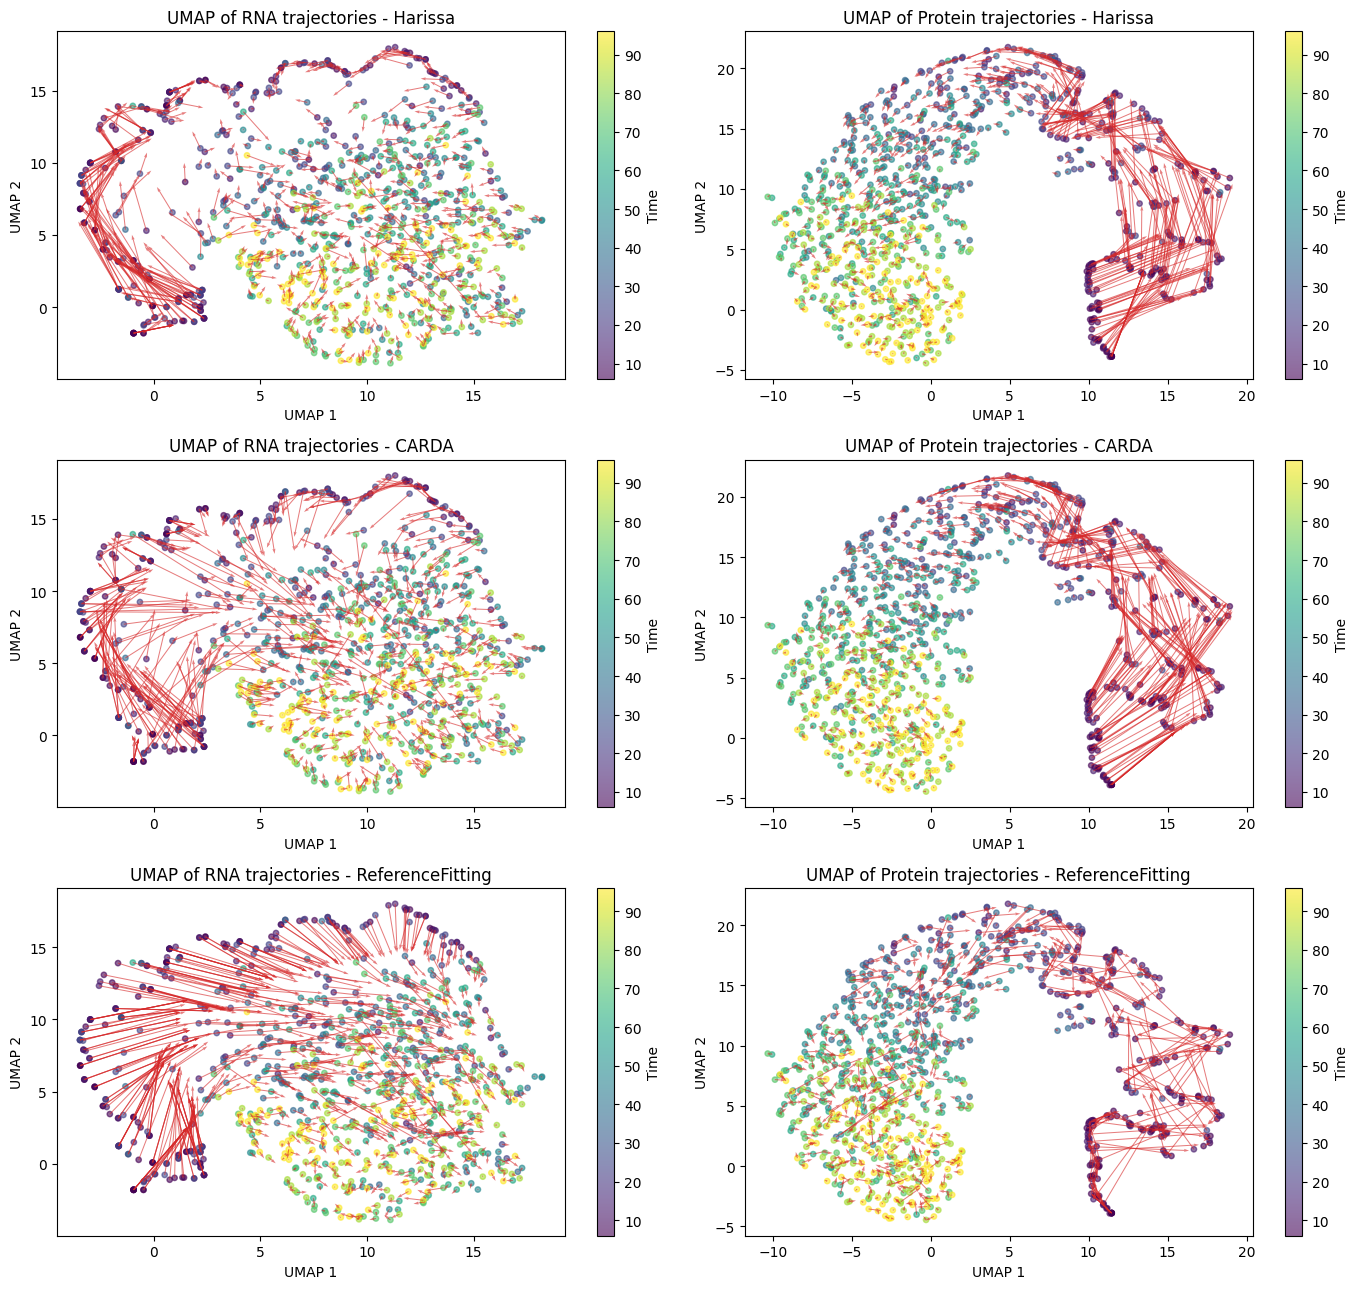

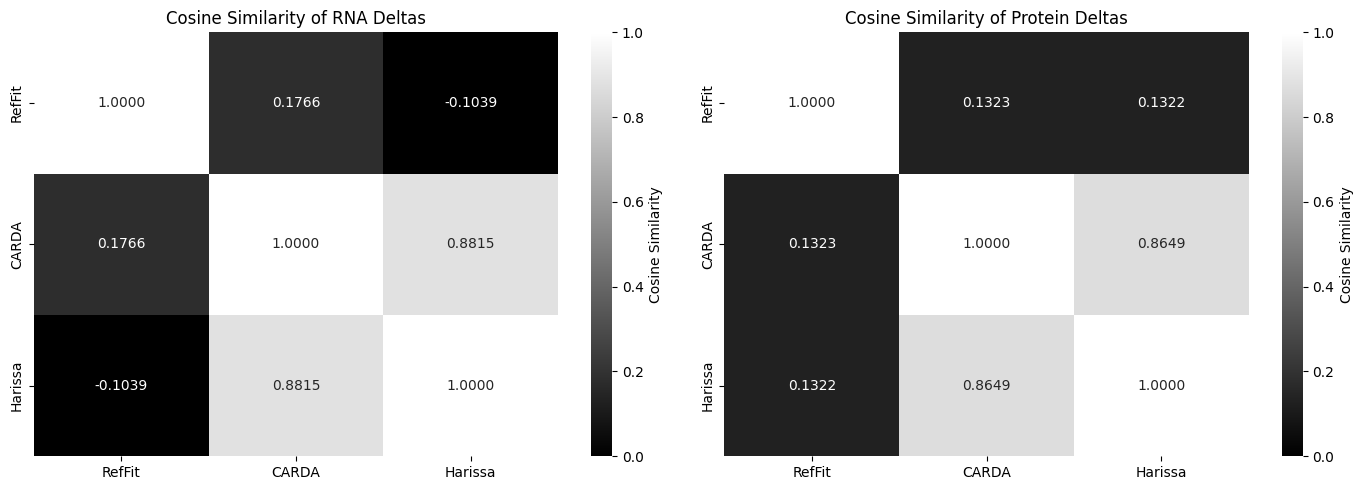

In [11]:
FN4_RNA, FN4_prot, FN4_UMAPs, FN4_cells = run_fig_5('FN4')

# Schiebinger

## Model Fit
Model is fitted from data is this subsection. We load pre-fitted weigths in the following subsection for reduced compute time and figure reproducibility

In [ ]:
adata = sc.read('../../../../data/Datas_exp/Schiebinger/Data/data_train.h5ad')
n_per_time = 50
np.random.seed(0)
time_vals = np.array(adata.obs['time'])
subsample_indices = []
for t in np.unique(time_vals):
    time_indices = np.where(time_vals == t)[0]
    n_sample = min(n_per_time, len(time_indices))
    sampled = np.random.choice(time_indices, size=n_sample, replace=False)
    subsample_indices.extend(sampled)
adata = adata[np.array(subsample_indices)].copy()

In [ ]:
time_schiebinger = np.array(adata.obs['time'])
rna_traj = adata.X.toarray().copy()
x = adata.X.toarray().copy()
x = np.insert(x, 0, time_schiebinger, axis=1)
G = np.size(x, 1)
model = CardamomNetworkModel(G - 1)
print(x.shape)
model.fit_mixture(x, gene_names=list(adata.var_names), 
                    min_components=2, max_components=2, max_iter_kinetics=0)
model.fit_network(x, intensity_prior=100)
model.adapt_to_unitary()

# Calculation of delta on Carda
c = model.a[-1]
ks_cells = np.max(model.a[:-1], axis=0)
ks = (model.a[:-1] / np.max(model.a[:-1], axis=0)).T
d0 = model.d[0]
d1 = model.d[1]

(1850, 109)


2026-02-10 11:15:50.710780: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710786: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710783: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710783: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710786: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710789: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710784: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-10 11:15:50.710780: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-

Calibrating gene 7
Calibrating gene 11
Calibrating gene 19
Calibrating gene 1
Calibrating gene 18
Calibrating gene 15
Calibrating gene 14
Calibrating gene 8
Calibrating gene 5
Calibrating gene 10
Calibrating gene 12
Calibrating gene 6
Calibrating gene 3
Calibrating gene 4
Calibrating gene 13
Calibrating gene 16
Calibrating gene 9
Calibrating gene 17
Calibrating gene 2
Calibrating gene 20
Calibrating gene 21
Calibrating gene 22
Calibrating gene 23
Calibrating gene 24
Calibrating gene 25
Calibrating gene 26
Calibrating gene 27
Calibrating gene 28
Calibrating gene 29
Calibrating gene 30
Calibrating gene 31
Calibrating gene 32
Calibrating gene 33
Calibrating gene 34
Calibrating gene 35
Calibrating gene 36
Calibrating gene 37
Calibrating gene 38
Calibrating gene 39
Calibrating gene 40
Calibrating gene 41
Calibrating gene 42
Calibrating gene 43
Calibrating gene 44
Calibrating gene 45
Calibrating gene 46
Calibrating gene 47
Calibrating gene 48
Calibrating gene 49
Calibrating gene 50
Calibrati

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


3 0 | Errors (before, after): 0.38139, 0.37507 | alpha mean: 0.1724
number of non reached cells 648


...

Minimization failed for refining
8 0 | Errors (before, after): 0.35076, 0.34644 | alpha mean: 0.2776
number of non reached cells 577


/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


9 0 | Errors (before, after): 0.34515, 0.34108 | alpha mean: 0.2935
number of non reached cells 539


/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Minimization failed for refining
10 0 | Errors (before, after): 0.34117, 0.33763 | alpha mean: 0.2953
number of non reached cells 503
Minimization failed for refining
11 0 | Errors (before, after): 0.34424, 0.34048 | alpha mean: 0.2955
number of non reached cells 497
12 1 | Errors (before, after): 0.34069, 0.33752 | alpha mean: 0.3051
number of non reached cells 471
13 1 | Errors (before, after): 0.33836, 0.33538 | alpha mean: 0.3073
number of non reached cells 463
Minimization failed for refining
14 1 | Errors (before, after): 0.33762, 0.33416 | alpha mean: 0.3057
number of non reached cells 453
15 1 | Errors (before, after): 0.33584, 0.33278 | alpha mean: 0.3106
number of non reached cells 444
Minimization failed for refining
16 1 | Errors (before, after): 0.33548, 0.33251 | alpha mean: 0.3108
number of non reached cells 423
17 1 | Errors (before, after): 0.33497, 0.33239 | alpha mean: 0.3196
number of non reached cells 424
18 1 | Errors (before, after): 0.33339, 0.33061 | alpha mean

## Loading weights

In [12]:
rna_traj = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/data_rna.npy')[:,1:]
G = rna_traj.shape[1]
model = CardamomNetworkModel(G)
model.d = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/degradations.npy')
model.basal = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/basal_simul.npy')
model.inter = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/inter_simul.npy')
model.prot = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/data_prot.npy')
model.kon_theta = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/data_kon_theta.npy')
model.a = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/mixture_parameters.npy')
time_schiebinger = np.load('../../../../data/Datas_exp/Schiebinger/cardamom/data_times.npy')

# Subsample 25 cells per time point to plot
n_per_time = 200
np.random.seed(0)
subsample_indices = []
for t in np.unique(time_schiebinger):
    time_indices = np.where(time_schiebinger == t)[0]
    n_sample = min(n_per_time, len(time_indices))
    sampled = np.random.choice(time_indices, size=n_sample, replace=False)
    subsample_indices.extend(sampled)
subsample_indices = np.array(subsample_indices)

time_schiebinger = time_schiebinger[subsample_indices]
rna_traj = rna_traj[subsample_indices]
model.prot = model.prot[subsample_indices]
model.kon_theta = model.kon_theta[subsample_indices]

c = model.a[-1]
ks_cells = np.max(model.a[:-1], axis=0)
ks = (model.a[:-1] / np.max(model.a[:-1], axis=0)).T
d0 = model.d[0]
d1 = model.d[1]

## Delta/UMAP calculation

In [13]:
infered_prot_traj = model.prot[:, 1:]
delta_rna_carda = d0[1:] * (model.kon_theta[:, 1:] * ks_cells[1:] / c[1:] - rna_traj)
delta_prot_carda = np.zeros_like(infered_prot_traj, dtype=float)
for cell in range(infered_prot_traj.shape[0]):
   Pnew, delta_P = step_ode_modif(d1[1:]*50, ks[1:], model.inter[1:, 1:], model.basal[1:], 1
                               , infered_prot_traj[cell].reshape(1, -1))
   delta_prot_carda[cell] = delta_P[0]

k = 8
if False:
   n_rows, n_cols = delta_prot_carda.shape
   k = min(k, n_cols)
   topk_idx = np.argpartition(np.abs(delta_prot_carda), -k, axis=1)[:, -k:]
   mask = np.zeros_like(delta_prot_carda, dtype=bool)
   rows = np.arange(n_rows)[:, None]
   mask[rows, topk_idx] = True
   delta_prot_carda[:] = np.where(mask, delta_prot_carda, 0.0)
if True:
   n_rows, n_cols = delta_rna_carda.shape
   k = min(k, n_cols)
   topk_idx = np.argpartition(np.abs(delta_rna_carda), -k, axis=1)[:, -k:]
   mask = np.zeros_like(delta_rna_carda, dtype=bool)
   rows = np.arange(n_rows)[:, None]
   mask[rows, topk_idx] = True
   delta_rna_carda[:] = np.where(mask, delta_rna_carda, 0.0)

umap_x = UMAP(n_components=2, random_state=42, min_dist=0.7)
umap_prot = UMAP(n_components=2, random_state=42, min_dist=0.7)
rna_endpoints = rna_traj + delta_rna_carda
prot_endpoints = infered_prot_traj + delta_prot_carda
rna_endpoints = np.maximum(rna_endpoints, 0)
prot_endpoints = np.maximum(prot_endpoints, 0)
rna_traj_adata = ad.AnnData(X=rna_traj.copy())
rna_endpoints_adata = ad.AnnData(X=rna_endpoints.copy())
sc.pp.normalize_total(rna_traj_adata, target_sum=1e4)
sc.pp.normalize_total(rna_endpoints_adata, target_sum=1e4)
sc.pp.log1p(rna_traj_adata)
sc.pp.log1p(rna_endpoints_adata)
rna_traj = rna_traj_adata.X.copy()
rna_endpoints = rna_endpoints_adata.X.copy()

umap_x.fit(rna_traj)
umap_prot.fit(infered_prot_traj)
rna_traj_2d = umap_x.transform(rna_traj)
prot_traj_2d = umap_prot.transform(infered_prot_traj)
delta_rna_carda_2d = (umap_x.transform(rna_endpoints) - rna_traj_2d)
delta_prot_carda_2d = (umap_prot.transform(prot_endpoints) - prot_traj_2d)

# Fig

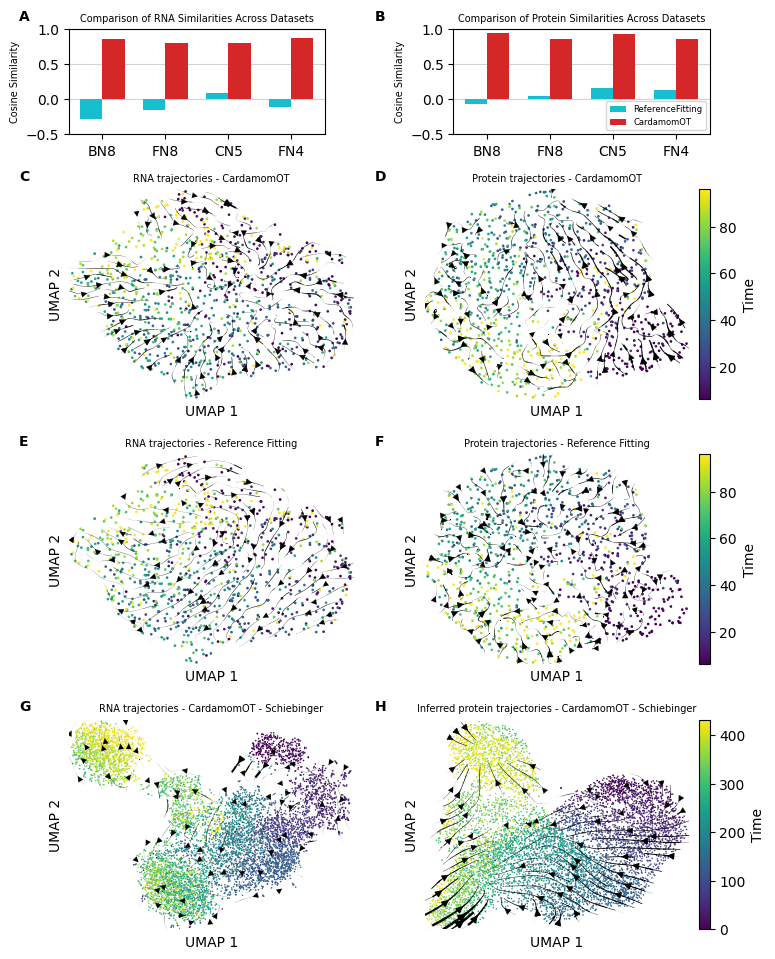

In [18]:

import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- Figure layout ---
fig = plt.figure(figsize=(8.27, 11.69))
gs = gridspec.GridSpec(4, 1, figure=fig, height_ratios=[1, 2, 2, 2], hspace=0.3)
wspaces = [0.5, 0.25, 0.25, 0.25]
subplot_specs = [gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[i], wspace=w)
                 for i, w in enumerate(wspaces)]
axes = [fig.add_subplot(spec[0, c]) for spec in subplot_specs for c in range(2)]

# --- Panel labels ---
x_left  = min(axes[i].get_position().x0 for i in range(0, 8, 2))
x_right = min(axes[i].get_position().x0 for i in range(1, 8, 2))
x_offset = 0.06
for i, (ax, label) in enumerate(zip(axes, "ABCDEFGH")):
    x_fig = (x_left if i % 2 == 0 else x_right) - x_offset
    fig.text(x_fig, ax.get_position().y1 + 0.005, label,
             ha="left", va="bottom", fontsize=10, fontweight="bold", clip_on=False)

# --- Bar charts (RNA left, Protein right) ---
dataset_titles = ['BN8', 'FN8', 'CN5', 'FN4']
bar_methods    = ['ReferenceFitting', 'CardamomOT']
bar_colors     = [colors_methods['REFERENCE_FITTING'][0], colors_methods['CardamomOT'][0]]
x = np.arange(len(dataset_titles))
width = 0.35

bar_configs = [
    (axes[0], [BN8_RNA,  FN8_RNA,  CN5_RNA,  FN4_RNA],  'Comparison of RNA Similarities Across Datasets',     (-0.5, 1), False),
    (axes[1], [BN8_prot, FN8_prot, CN5_prot, FN4_prot], 'Comparison of Protein Similarities Across Datasets', (-0.5, 1), True),
]
for ax, matrices, title, ylim, show_legend in bar_configs:
    for idx, (method, color) in enumerate(zip(bar_methods, bar_colors)):
        ax.bar(x + idx * width, [m[2, idx] for m in matrices], width, label=method, color=color)
    ax.set_ylabel('Cosine Similarity', fontsize=7)
    ax.set_title(title, fontsize=7)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(dataset_titles)
    ax.set_ylim(*ylim)
    ax.yaxis.grid(True, color='lightgray', linewidth=0.8)
    ax.set_axisbelow(True)
    if show_legend:
        ax.legend(loc='lower right', fontsize=6)

# --- Velocity stream helper ---
DENSITY, SMOOTH = 1, 0.5

def make_adata_plot(embedding, velocity, time_vals):
    ap = ad.AnnData(X=embedding.astype(np.float32))
    ap.obs['time'] = time_vals.astype(float)
    ap.obsm['X_umap'] = embedding
    ap.obsm['velocity_umap'] = velocity
    return ap

def plot_stream(ax, embedding, velocity, time_vals, title, size=15, add_colorbar=False):
    scv.pl.velocity_embedding_stream(
        make_adata_plot(embedding, velocity, time_vals),
        basis='umap', ax=ax, color='time', cmap='viridis',
        alpha=1, size=size, show=False, colorbar=False, density=DENSITY, smooth=SMOOTH)
    ax.set(xlabel='UMAP 1', ylabel='UMAP 2', title=title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.title.set_fontsize(7)
    if add_colorbar:
        sm = ScalarMappable(cmap='viridis', norm=Normalize(vmin=time_vals.min(), vmax=time_vals.max()))
        sm.set_array([])
        cax = make_axes_locatable(ax).append_axes("right", size="4%", pad=0.1)
        plt.colorbar(sm, cax=cax, label='Time')

# --- CN5 protein UMAP ----
fn4_time = time[100:].astype(float)
prot_CN5 = CN5_cells['prot']
prot_traj_2d_CN5, (delta_prot_carda_2d_CN5, delta_prot_reffit_2d_CN5) = fit_transform_umap(
    prot_CN5,
    prot_CN5 + CN5_cells['prot_carda'],
    prot_CN5 + CN5_cells['prot_reffit'] * 0.1,
    n_components=2, random_state=42, min_dist=0.7)

# --- Stream plots ---
stream_configs = [
    (axes[2], CN5_UMAPs['rna'],  CN5_UMAPs['rna_carda'],    fn4_time,         'RNA trajectories - CardamomOT',                            15, False),
    (axes[3], prot_traj_2d_CN5,  delta_prot_carda_2d_CN5,   fn4_time,         'Protein trajectories - CardamomOT',                        15, True),
    (axes[4], CN5_UMAPs['rna'],  CN5_UMAPs['rna_reffit'],   fn4_time,         'RNA trajectories - Reference Fitting',                     15, False),
    (axes[5], prot_traj_2d_CN5,  delta_prot_reffit_2d_CN5,  fn4_time,         'Protein trajectories - Reference Fitting',                 15, True),
    (axes[6], rna_traj_2d,       delta_rna_carda_2d,        time_schiebinger, 'RNA trajectories - CardamomOT - Schiebinger',               5, False),
    (axes[7], prot_traj_2d,      delta_prot_carda_2d,       time_schiebinger, 'Inferred protein trajectories - CardamomOT - Schiebinger',  5, True),
]
for ax, emb, vel, t, title, size, cbar in stream_configs:
    plot_stream(ax, emb, vel, t, title, size=size, add_colorbar=cbar)

plt.subplots_adjust(hspace=0.2, wspace=0.25)
plt.savefig('figure_5_comparison_combined.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
plt.show()


In [19]:
import importlib, subprocess, sys
if importlib.util.find_spec("PIL") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "Pillow"])
from PIL import Image

img_path = "figure_5_comparison_combined.png"
pdf_path = "figure_5_comparison_combined.pdf"

im = Image.open(img_path)
im.convert('RGB').save(pdf_path, "PDF", resolution=600)
print('Saved', pdf_path)

Saved figure_5_comparison_combined.pdf
